```
<10_human_face.ipynb>

제미나이 의존도: 60-70%

이번엔 xml 말고 csv 파일이 있는 객체탐지 데이터셋을 골랐다.
캐글에 xml에 라벨을 관리해둔 데이터셋이 눈씻고 찾아봐도 없었고, 대부분 csv, json 형식이었다.
csv 파일을 판다스로 읽는 건 그렇게 낯설지 않았지만 groupby()를 써야하는 상황이 됐다.
하나의 이미지에 여러가지 객체가 있을 수 있기 때문이다.
groupby() 해서 요리하는 과정에서 제미나이의 도움을 받았다..
```

```
목표 및 포부
캐글에서 새로운 데이터셋 가져온다(xml 파일 포함된 데이터셋)
그걸 가져와서 내가 요리조리 수정해서 txt로 변환하여
YOLOv8 모델이 학습하기 좋게 만든다.
의존도는 최소한으로 가져가면서..

0. Pandas로 CSV 불러오기: pd.read_csv() 활용
1. 클래스명 -> ID 매핑 Dict 만들기: ({'apple': 0, 'banana': 1})
2. 이미지 파일별로 grouping하기: df.groupby('image_id')를 사용하면 이미지 1개에 속한 모든 바운딩 박스를 한번에 처리
3. PIL 또는 OpenCV로 이미지 너비 높이 구하기
4. 정규화 공식 적용 후 .txt 파일로 저장하기

```

In [19]:
import pandas as pd
import os
import random
import shutil
from ultralytics import YOLO
import time
%matplotlib inline
import matplotlib.pyplot as plt
import cv2

In [32]:

class_map = {0: 'face'}

csv_path = "dataset/human_faces/human-faces-object-detection/faces.csv"
df = pd.read_csv(csv_path)
# df.head()
# 	image_name  	width	height	x0	y0	x1	 y1
# 0	00001722.jpg	1333	2000	490	320	687	 664
# 1	00001044.jpg	2000	1333	791	119	1200 436
# 2	00001050.jpg	667	    1000	304	155	407	 331
# 3	00001736.jpg	626	    417	    147	14	519	 303
# 4	00003121.jpg	626	    418	    462	60	599	 166

# print(df.loc[0, 'width'])
# print(df.loc[0]['width'])

# df.groupby('image_name')

# print(df.head())


#        image_name  width  height   x0  y0   x1  y1
# 586  00000003.jpg    500     350  101  25  176  87

for img_name, group in df.groupby('image_name'):
    # group 안에는 특정 img_name에 해당하는 행들이 들어있음.

    # if len(group) >= 2:
    #     print(f"얼굴이 여러 개 있는 이미지: {img_name} ({len(group)}개)")

    # 텍스트 파일에 쓸 한줄 한줄을 모을 리스트
    txt_lines = []

    # group 내부의 각 행을 순회
    for idx, row in group.iterrows():
        w_img = row['width']
        h_img = row['height']
        xmin, ymin, xmax, ymax = row['x0'], row['y0'], row['x1'], row['y1']

        x_center = (xmin + xmax) / (w_img * 2)
        y_center = (ymin + ymax) / (h_img * 2)
        w = (xmax - xmin) / w_img
        h = (ymax - ymin) / h_img

        line = f"0 {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}"
        txt_lines.append(line)

    pure_name, ext = os.path.splitext(img_name)
    txt_path = f"dataset/human_faces/human-faces-object-detection/labels/{pure_name}.txt"
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write('\n'.join(txt_lines) + '\n')



In [14]:
src_image_path = "dataset/human_faces/human-faces-object-detection/images"
image_list = [f for f in os.listdir(src_image_path) if f.endswith(('.jpg', '.jpeg', '.png', '.webp'))]

src_txt_path = "dataset/human_faces/human-faces-object-detection/labels"
txt_list = os.listdir(src_txt_path)
txt_set = set(txt_list)

random.seed(42)
random.shuffle(image_list)

split_idx = int(len(image_list) * 0.8)
train_images = image_list[:split_idx]
val_images = image_list[split_idx:]

split_data = {"train": train_images, "valid": val_images}

for split_type, images in split_data.items():
    count = 0
    dest_path = "dataset/human_faces"
    dest_image_path = os.path.join(dest_path, f"{split_type}/images")
    dest_txt_path = os.path.join(dest_path, f"{split_type}/labels")

    os.makedirs(dest_image_path, exist_ok=True)
    os.makedirs(dest_txt_path, exist_ok=True)
    
    for image in images:
        pure_name, ext = os.path.splitext(image)
        txt_name = f"{pure_name}.txt"
        if txt_name in txt_set: # 이미지도 텍스트도 둘 다 존재할 때
            # image는 train/images에 복사
            # txt는 train/labels에 복사
            src_image_full_path = os.path.join(src_image_path, image)
            dest_image_full_path = os.path.join(dest_image_path, image)
            shutil.copy(src_image_full_path, dest_image_full_path)
    
            src_txt_full_path = os.path.join(src_txt_path, txt_name)
            dest_txt_full_path = os.path.join(dest_txt_path, txt_name)
            shutil.copy(src_txt_full_path, dest_txt_full_path)
            count += 1
    print(f"{types} count: {count}")

train count: 1763
valid count: 441


In [15]:
yaml_path = "dataset/human_faces/data.yaml"
with open(yaml_path, "w", encoding="utf-8") as f:
    f.write("train: ../train/images\n")
    f.write("val: ../valid/images\n")
    f.write("\n")
    f.write("nc: 1\n")
    f.write("names: ['face']")

In [17]:
model = YOLO('yolov8n.pt')

current_dir = os.getcwd()

start_time = time.time()
model.train(
    data='dataset/human_faces/data.yaml', 
    epochs=15, 
    imgsz=640, 
    device='mps', 
    project=os.path.join(current_dir, 'runs'), 
    name='human_face'
)

end_time = time.time()
elapsed_time = int(end_time - start_time)
mins, secs = divmod(elapsed_time, 60)
print(f"{mins}:{secs}")

New https://pypi.org/project/ultralytics/8.4.104 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/human_faces/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=human_face, nbs

In [22]:
def inspect_detection(image_path, conf_threshold=0.45, iou_threshold=0.3):
    model = YOLO('runs/human_face/weights/best.pt')

    preds = model.predict(
        source=image_path, 
        conf=conf_threshold, 
        iou=iou_threshold, 
        device='mps'
    )

    annotated_img = preds[0].plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_img_rgb)
    plt.title(f"Conf: {conf_threshold} | IoU: {iou_threshold}", fontsize=12)
    plt.axis('off')
    plt.show()


image 1/1 /Users/jeongjaehun/Github/03_object_detection/dataset/50696_60739_241.jpg: 448x640 1 face, 9.3ms
Speed: 2.1ms preprocess, 9.3ms inference, 2.1ms postprocess per image at shape (1, 3, 448, 640)


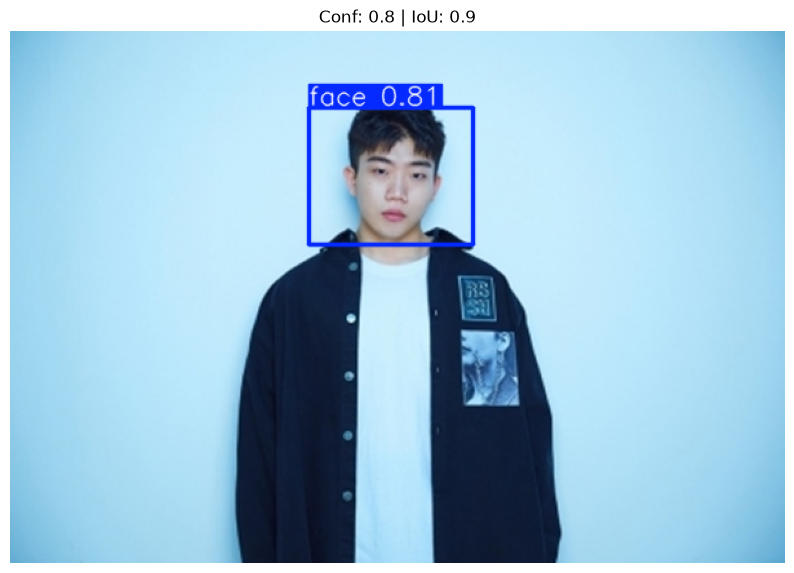

In [33]:
image_path = 'dataset/50696_60739_241.jpg'
inspect_detection(image_path, conf_threshold=0.80, iou_threshold=0.9)